In [158]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [159]:
pd.set_option('display.max_columns', None)

In [160]:
df = pd.read_csv(r'deforestation_hotspot_dataset.csv')

In [161]:
df.shape

(15000, 21)

In [162]:
df.head()

,region,biome,latitude,longitude,year,primary_driver,forest_loss_ha,annual_rainfall_mm,avg_temp_c,ndvi_before,ndvi_after,soil_carbon_tonne_ha,slope_degrees,elevation_m,dist_to_road_km,dist_to_settlement_km,population_density,protected_area,fire_incidents,carbon_emissions_tco2e,is_hotspot
0,Congo Basin,Tropical Rainforest,-0.2306,25.6300,2010,Agricultural Expansion,1749.14,2425.0,26.04,0.9029,0.7455,44.87,3.70,305,2.60,58.74,9.3,No,3,428974.30,1
1,Gran Chaco,Tropical Dry Forest,-21.4987,-63.3336,2010,Logging,3073.18,2729.9,26.05,0.5600,0.3489,35.64,4.56,388,10.24,55.58,8.3,No,3,1018574.35,1
2,West Africa,Tropical Rainforest,3.4846,-7.2454,2007,Cattle Ranching,5609.01,2262.4,24.06,0.6165,0.2510,72.99,0.65,2011,33.88,15.03,29.0,Yes,6,1345862.75,1
3,Cerrado Brazil,Tropical Savanna,-16.9371,-46.4768,2020,Agricultural Expansion,7410.69,1151.6,24.02,0.8915,0.5860,109.77,4.16,176,26.15,10.42,20.1,Yes,4,2330234.94,1
4,Amazon Basin,Tropical Rainforest,-3.4336,-64.5906,2014,Logging,2470.70,1395.1,22.37,0.9342,0.8038,67.49,15.01,781,12.87,24.06,43.0,No,3,465216.72,1


In [163]:
df.tail()

,region,biome,latitude,longitude,year,primary_driver,forest_loss_ha,annual_rainfall_mm,avg_temp_c,ndvi_before,ndvi_after,soil_carbon_tonne_ha,slope_degrees,elevation_m,dist_to_road_km,dist_to_settlement_km,population_density,protected_area,fire_incidents,carbon_emissions_tco2e,is_hotspot
14995,Central America,Tropical Rainforest,8.8786,-80.0666,2014,Agricultural Expansion,3674.11,1998.3,25.56,0.5794,0.3680,38.49,3.20,89,48.35,12.83,1.8,Yes,1,852960.17,1
14996,Amazon Basin,Tropical Rainforest,0.2499,-65.1990,2007,Cattle Ranching,1468.15,2178.9,21.09,0.7885,0.5869,28.67,4.99,151,48.60,33.69,6.4,No,4,418393.65,0
14997,Amazon Basin,Tropical Rainforest,-0.1955,-64.6686,2021,Agricultural Expansion,1379.32,2615.8,21.88,0.8534,0.7387,111.40,0.85,689,4.88,9.73,6.6,No,2,251502.14,0
14998,Central America,Tropical Rainforest,8.0556,-85.1727,2001,Logging,1727.06,2360.5,27.74,0.8330,0.5692,59.70,1.10,832,0.63,9.68,16.2,No,5,492123.57,1
14999,Amazon Basin,Tropical Rainforest,-5.1707,-59.3899,2014,Cattle Ranching,2443.01,1844.5,29.49,0.8602,0.4964,39.06,1.16,266,5.13,7.34,12.5,No,1,642577.50,1


In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   region                  15000 non-null  object 
 1   biome                   15000 non-null  object 
 2   latitude                15000 non-null  float64
 3   longitude               15000 non-null  float64
 4   year                    15000 non-null  int64  
 5   primary_driver          15000 non-null  object 
 6   forest_loss_ha          15000 non-null  float64
 7   annual_rainfall_mm      15000 non-null  float64
 8   avg_temp_c              15000 non-null  float64
 9   ndvi_before             15000 non-null  float64
 10  ndvi_after              15000 non-null  float64
 11  soil_carbon_tonne_ha    15000 non-null  float64
 12  slope_degrees           15000 non-null  float64
 13  elevation_m             15000 non-null  int64  
 14  dist_to_road_km         15000 non-null

In [165]:
df.describe()

,latitude,longitude,year,forest_loss_ha,annual_rainfall_mm,avg_temp_c,ndvi_before,ndvi_after,soil_carbon_tonne_ha,slope_degrees,elevation_m,dist_to_road_km,dist_to_settlement_km,population_density,fire_incidents,carbon_emissions_tco2e,is_hotspot
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,1.500000e+04,15000.000000
mean,-2.710219,-9.727786,2012.026800,3862.455069,2101.563773,25.986380,0.751616,0.475378,75.950539,5.041694,334.285467,25.298521,40.322253,25.129647,2.991200,1.022888e+06,0.819067
std,10.780427,64.581722,6.635848,3420.638199,503.766917,2.973397,0.115521,0.154007,40.599143,5.047450,308.342528,25.222151,40.504478,45.298416,1.713938,9.465193e+05,0.384976
min,-26.978000,-87.997400,2001.000000,104.800000,400.000000,18.000000,0.550000,0.103600,11.230000,0.000000,13.000000,0.100000,0.500000,0.100000,0.000000,2.425382e+04,0.000000
25%,-6.902225,-62.066375,2006.000000,1476.720000,1768.075000,23.970000,0.651575,0.364900,47.707500,1.480000,142.000000,7.290000,11.500000,5.400000,2.000000,3.778852e+05,1.000000
50%,-1.606750,-45.360150,2012.000000,2929.520000,2100.400000,25.970000,0.752400,0.474900,66.640000,3.480000,243.000000,17.475000,27.545000,12.300000,3.000000,7.546021e+05,1.000000
75%,3.304975,26.630475,2018.000000,5141.050000,2437.825000,27.990000,0.851700,0.585725,94.152500,6.940000,416.000000,34.892500,55.372500,27.400000,4.000000,1.356248e+06,1.000000
max,23.996800,115.993100,2023.000000,39423.010000,3980.100000,35.000000,0.950000,0.847100,425.790000,45.000000,3500.000000,200.000000,300.000000,1139.800000,12.000000,1.113900e+07,1.000000


In [166]:
df.duplicated().sum()

np.int64(0)

In [167]:
df.isna().sum()

region                    0
biome                     0
latitude                  0
longitude                 0
year                      0
primary_driver            0
forest_loss_ha            0
annual_rainfall_mm        0
avg_temp_c                0
ndvi_before               0
ndvi_after                0
soil_carbon_tonne_ha      0
slope_degrees             0
elevation_m               0
dist_to_road_km           0
dist_to_settlement_km     0
population_density        0
protected_area            0
fire_incidents            0
carbon_emissions_tco2e    0
is_hotspot                0
dtype: int64

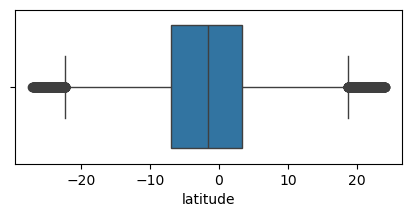

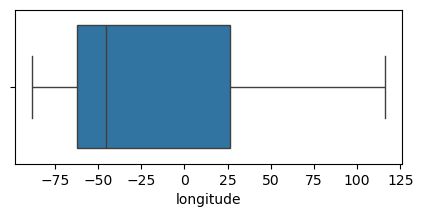

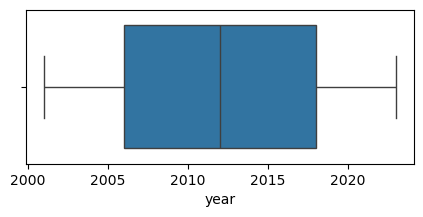

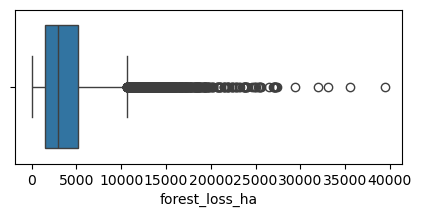

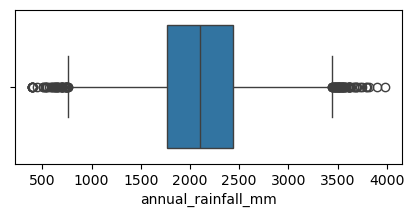

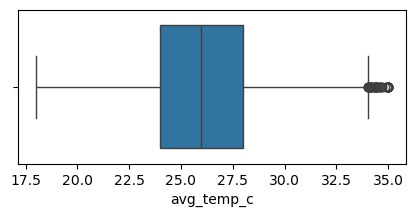

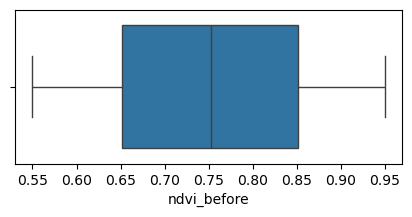

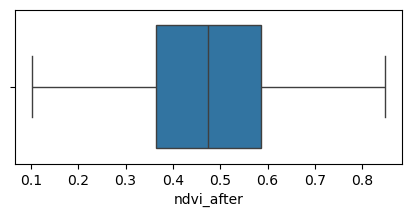

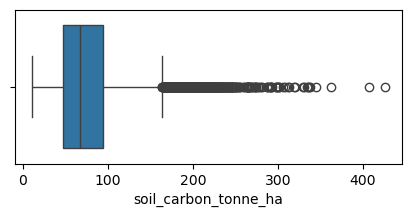

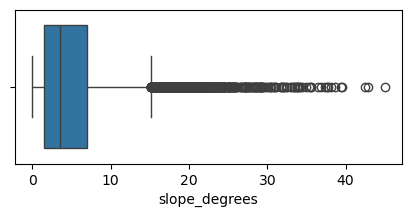

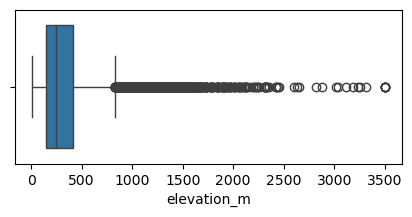

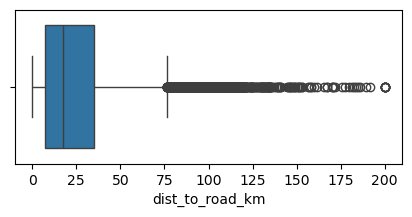

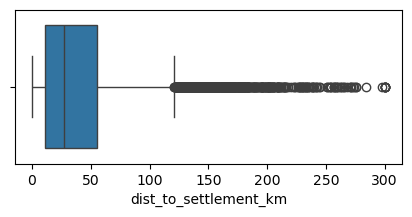

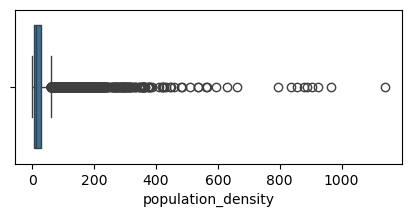

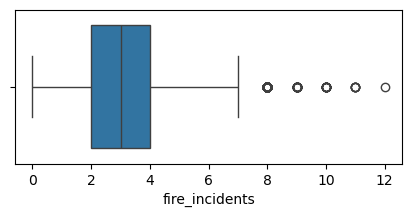

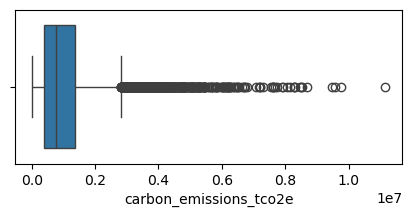

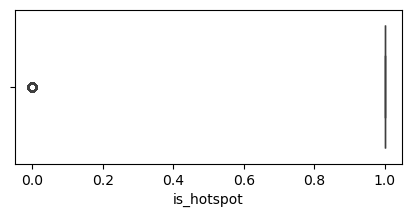

In [168]:
num_cols = df.select_dtypes(include=['float','int'])

for i in num_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[i])

Text(0.5, 1.0, ' Target Imbalance (is_hotspot)')

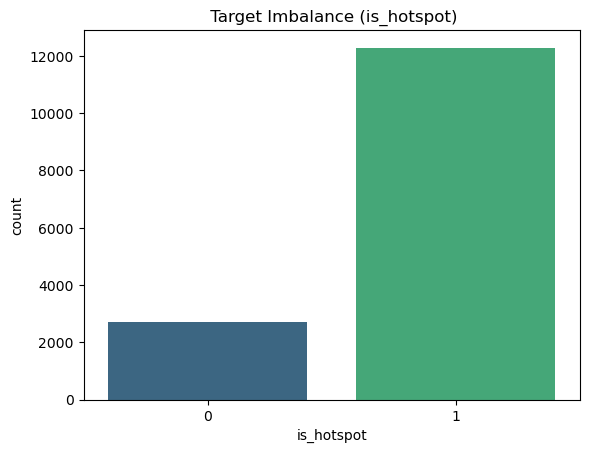

In [169]:
# Distribution of the Target Variable

sns.countplot(x='is_hotspot', data=df, palette='viridis')
plt.title(" Target Imbalance (is_hotspot)")

Text(0.5, 1.0, ' Distribution of Forest Loss (HA)')

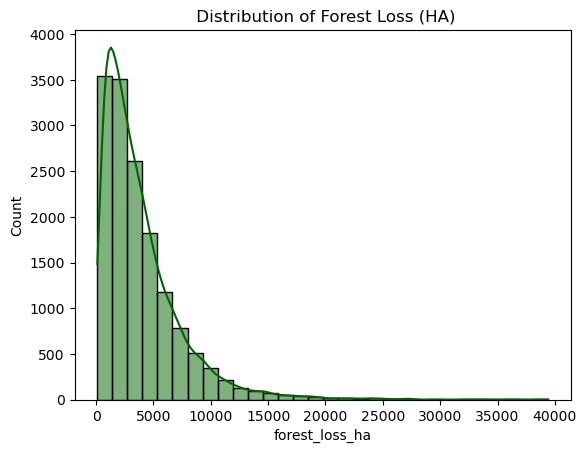

In [170]:
# Distribution of Forest Loss (Log scale)

sns.histplot(df['forest_loss_ha'], bins=30, kde=True, color='darkgreen')
plt.title(" Distribution of Forest Loss (HA)")

Text(0.5, 1.0, ' Distribution of Carbon Emissions')

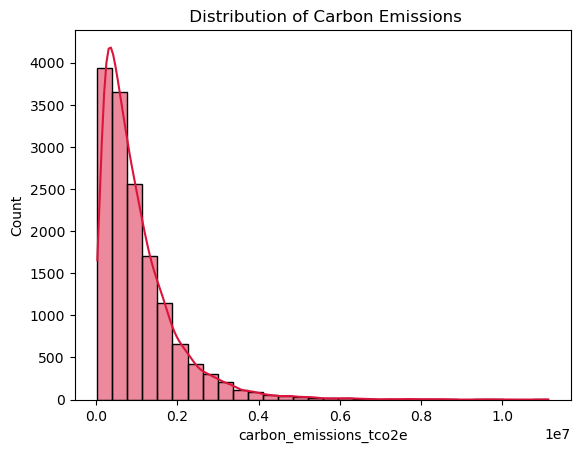

In [171]:
# Distribution of Carbon Emissions

sns.histplot(df['carbon_emissions_tco2e'], bins=30, kde=True,  color='crimson')
plt.title(" Distribution of Carbon Emissions")

Text(0.5, 1.0, ' Sample Count by Region')

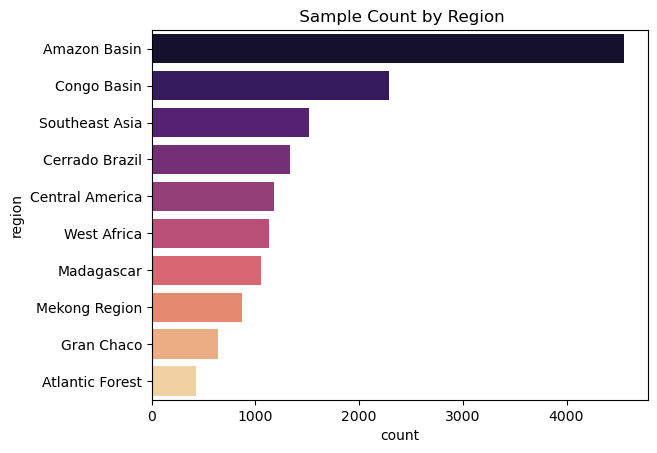

In [172]:
# Regional Distribution of Deforestation Instances

sns.countplot(y='region', data=df,  order=df['region'].value_counts().index, palette='magma')
plt.title(" Sample Count by Region")

Text(0.5, 1.0, ' Sample Count by Biome')

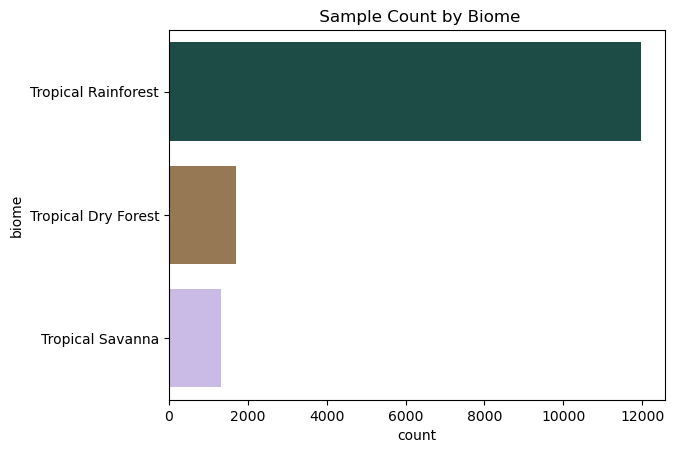

In [173]:
# Biome Occurrence Frequency

sns.countplot(y='biome', data=df, order=df['biome'].value_counts().index, palette='cubehelix')
plt.title(" Sample Count by Biome")

Text(0.5, 1.0, ' Core Drivers of Deforestation')

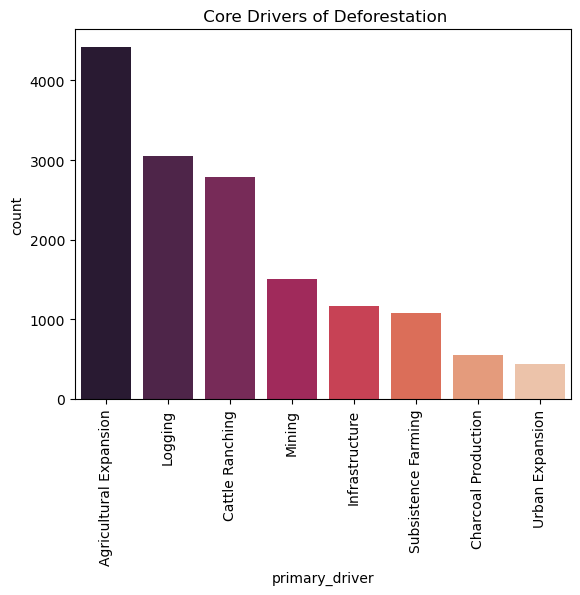

In [174]:
# Primary Drivers of Deforestation

sns.countplot(x='primary_driver', data=df, order=df['primary_driver'].value_counts().index, palette='rocket')
plt.tick_params(axis='x', rotation=90)
plt.title(" Core Drivers of Deforestation")

Text(0.5, 1.0, ' Correlation Matrix Heatmap')

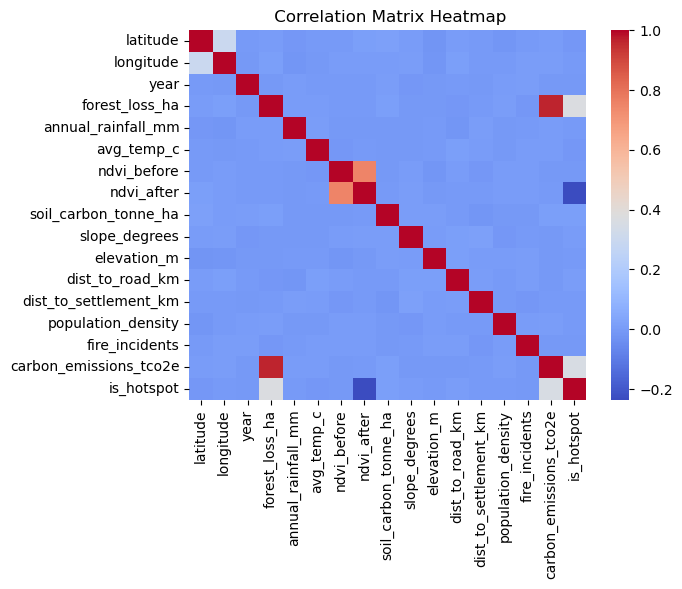

In [175]:
# Correlation Heatmap of Numeric Variables

numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm',  cbar=True)
plt.title(" Correlation Matrix Heatmap")

Text(0.5, 1.0, ' Vegetation Index (NDVI) Shift')

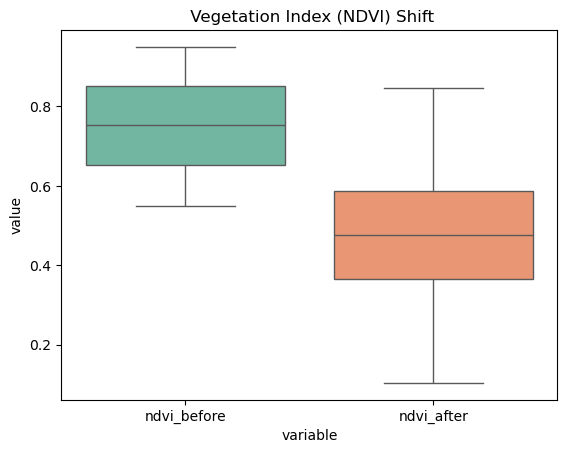

In [176]:
# NDVI Drop Analysis (Before vs After)

ndvi_melted = pd.melt(df[['ndvi_before', 'ndvi_after']])
sns.boxplot(x='variable', y='value', data=ndvi_melted,  palette='Set2')
plt.title(" Vegetation Index (NDVI) Shift")

Text(0.5, 1.0, ' Loss vs Emissions Scatterplot')

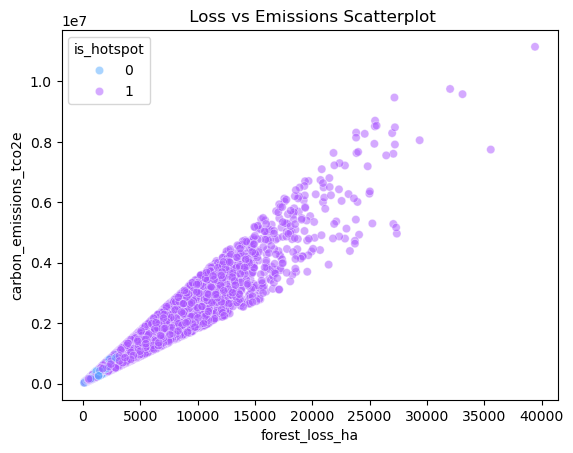

In [177]:
# Forest Loss vs Carbon Emissions by Hotspot Status

sns.scatterplot(x='forest_loss_ha', y='carbon_emissions_tco2e', hue='is_hotspot', data=df, alpha=0.5,  palette='cool')
plt.title(" Loss vs Emissions Scatterplot")

Text(0.5, 1.0, ' Fire Incidents Across Hotspots')

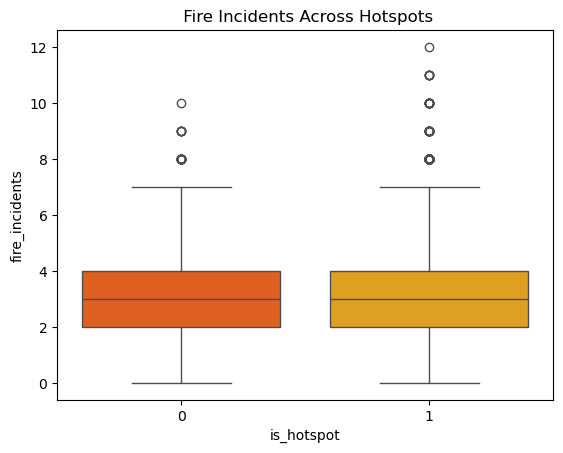

In [178]:
# Fire Incidents vs Hotspot Vulnerability

sns.boxplot(x='is_hotspot', y='fire_incidents', data=df,  palette='autumn')
plt.title(" Fire Incidents Across Hotspots")

Text(0.5, 1.0, ' Hotspot Rate in Protected Areas')

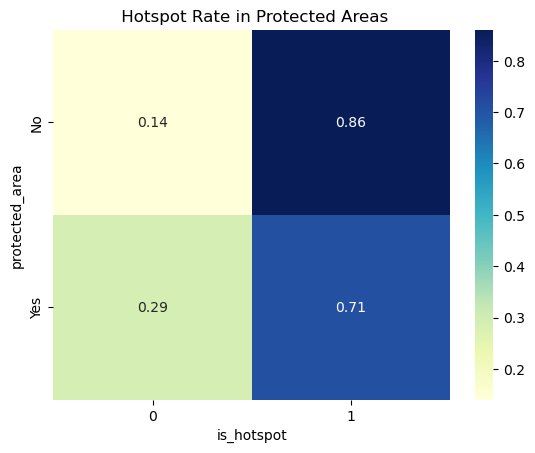

In [179]:
# Impact of Protected Areas on Hotspot Status

sns.heatmap(pd.crosstab(df['protected_area'], df['is_hotspot'], normalize='index'), annot=True, cmap='YlGnBu',  fmt=".2f")
plt.title(" Hotspot Rate in Protected Areas")

Text(0.5, 1.0, ' Spatial Layout of Biomes')

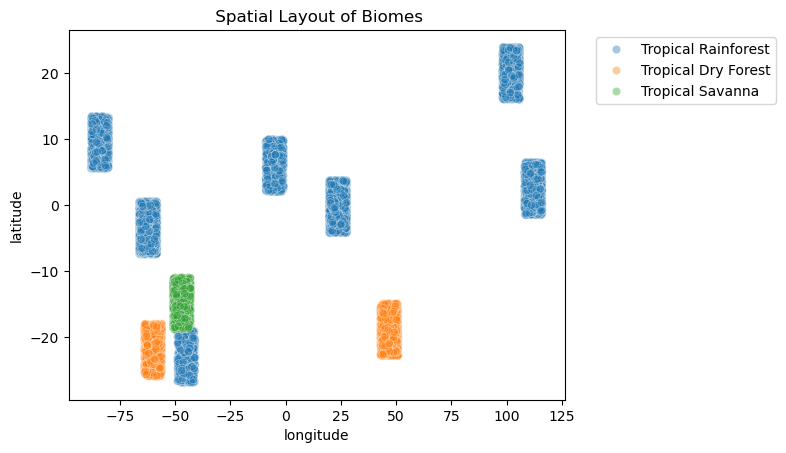

In [181]:
# Geographic Mapping (Lat/Lon) Colored by Biome

sns.scatterplot(x='longitude', y='latitude', hue='biome', data=df, alpha=0.4,  palette='tab10')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title(" Spatial Layout of Biomes")

Text(0.5, 1.0, ' Total Forest Loss Trend Over Years')

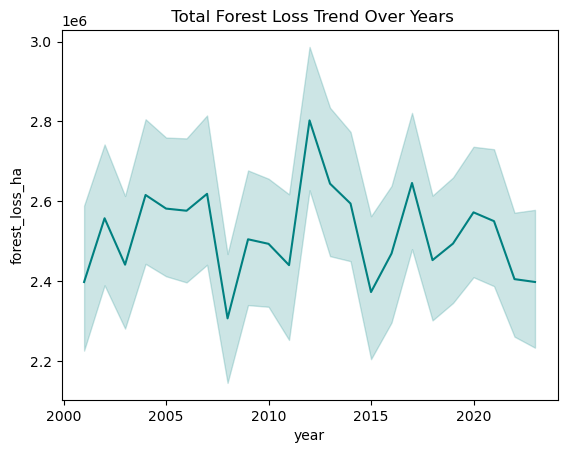

In [182]:
# Temporal Trend of Deforestation over the Years

sns.lineplot(x='year', y='forest_loss_ha', data=df,  color='teal', estimator='sum')
plt.title(" Total Forest Loss Trend Over Years")

Text(0.5, 1.0, ' Density Profile vs Hotspots')

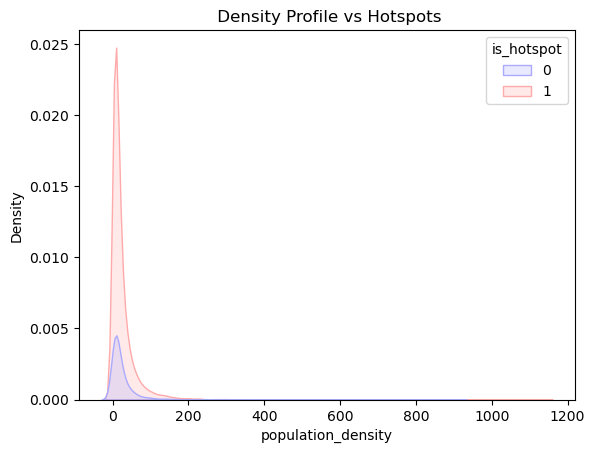

In [183]:
# Population Density Distribution

sns.kdeplot(x='population_density', hue='is_hotspot', data=df, shade=True,  palette='bwr')
plt.title(" Density Profile vs Hotspots")

Text(0.5, 1.0, ' Proximity Matrix to Human Infra')

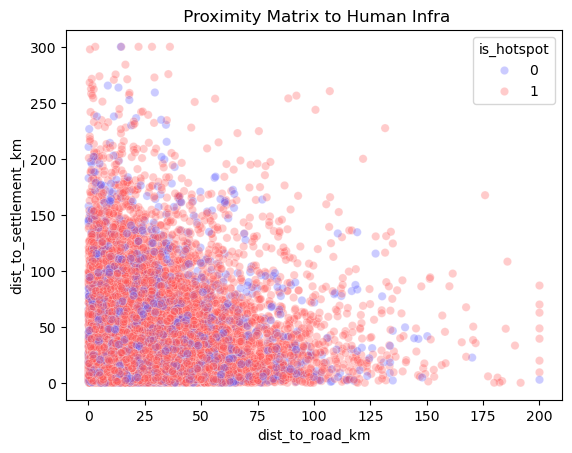

In [184]:
# Proximity to Infrastructure: Roads vs Settlements

sns.scatterplot(x='dist_to_road_km', y='dist_to_settlement_km', hue='is_hotspot', data=df, alpha=0.3,  palette='seismic')
plt.title(" Proximity Matrix to Human Infra")

Text(0.5, 1.0, ' Topographical Profile Density')

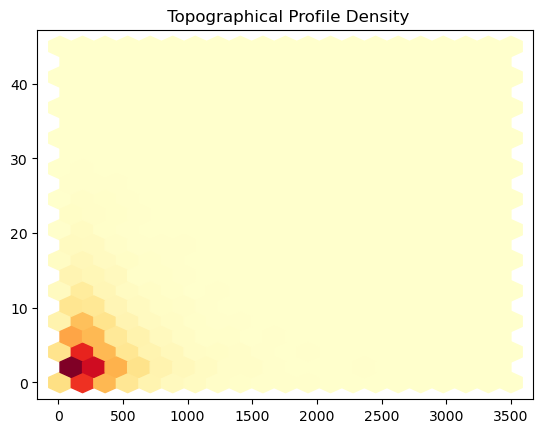

In [185]:
# Slope Degrees vs Elevation Profile

plt.hexbin(df['elevation_m'], df['slope_degrees'], gridsize=20, cmap='YlOrRd')
plt.title(" Topographical Profile Density")

Text(0.5, 1.0, ' Rainfall Variation across Drivers')

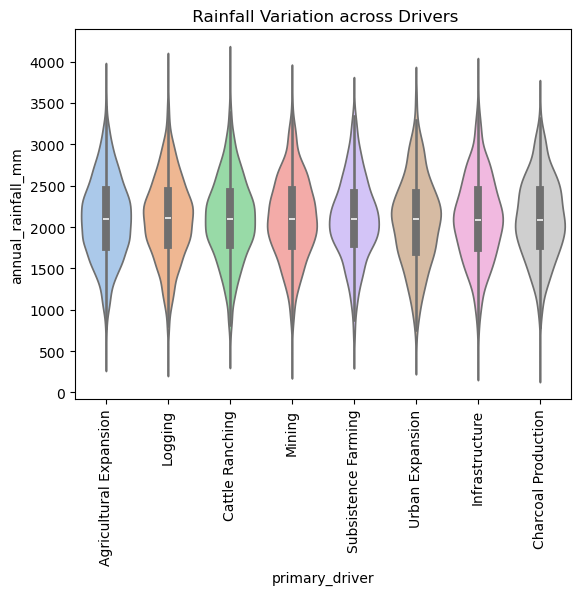

In [186]:
# Annual Rainfall Variance Across Key Drivers

sns.violinplot(x='primary_driver', y='annual_rainfall_mm', data=df, palette='pastel')
plt.tick_params(axis='x', rotation=90)
plt.title(" Rainfall Variation across Drivers")

Text(0.5, 1.0, ' Avg Soil Carbon Stock by Biome')

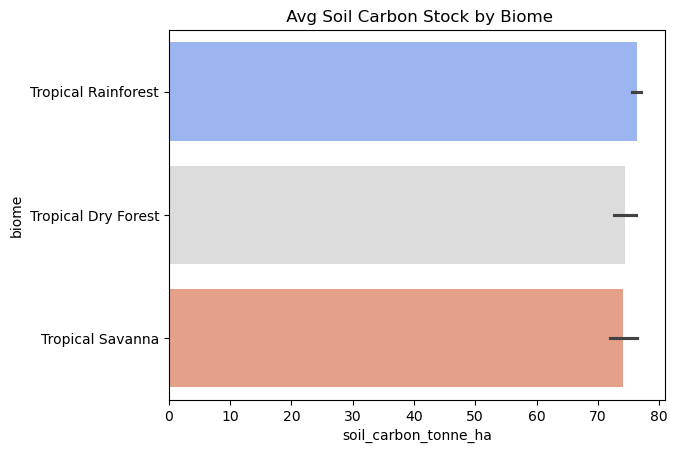

In [187]:
# Soil Carbon Stock vs Biome

sns.barplot(x='soil_carbon_tonne_ha', y='biome', data=df, palette='coolwarm')
plt.title(" Avg Soil Carbon Stock by Biome")

In [188]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score, confusion_matrix, roc_curve

In [189]:
cat_cols = df.select_dtypes('object')

label = LabelEncoder()
for col in cat_cols:
    df[col] = label.fit_transform(df[col])

In [190]:
x = df.drop('is_hotspot', axis=1)
y = df['is_hotspot']

In [191]:
scaler = StandardScaler()
x_scaler = scaler.fit_transform(x)

In [192]:
x_train, x_test, y_train, y_test = train_test_split(x_scaler, y, test_size=0.20, random_state=42)

In [193]:
rt = RandomForestClassifier()
rt.fit(x_train, y_train)

RandomForestClassifier()

In [194]:
y_pred = rt.predict(x_test)

In [195]:
print('Accuracy Score : ',accuracy_score(y_test, y_pred)*100)

Accuracy Score :  97.83333333333334


In [196]:
print('Precision Score : ',precision_score(y_test, y_pred)*100)

Precision Score :  98.099474322685


In [197]:
print('Recalll Score : ',recall_score(y_test, y_pred)*100)

Recalll Score :  99.26350245499181


In [198]:
print('F1 Score : ',f1_score(y_test, y_pred)*100)

F1 Score :  98.67805572503559


In [199]:
print('AUC-ROC : ',roc_auc_score(y_test, y_pred))

AUC-ROC :  0.9540513252245992


In [200]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.92      0.94       556
           1       0.98      0.99      0.99      2444

    accuracy                           0.98      3000
   macro avg       0.97      0.95      0.96      3000
weighted avg       0.98      0.98      0.98      3000



In [202]:
# RandomizedSearchCV Space

random_param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_base = RandomForestClassifier(random_state=42)

print("Executing RandomizedSearchCV...")
random_search = RandomizedSearchCV(estimator=rf_base, param_distributions=random_param_grid, 
                                   n_iter=5, cv=3, random_state=42, n_jobs=-1, scoring='roc_auc')
random_search.fit(x_train, y_train)
print(f"Best parameters from RandomSearch: {random_search.best_params_}")

Executing RandomizedSearchCV...
Best parameters from RandomSearch: {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}


In [203]:
# GridSearchCV Space centered around top Random Search estimators

grid_param_grid = {
    'n_estimators': [random_search.best_params_['n_estimators']],
    'max_depth': [random_search.best_params_['max_depth']],
    'criterion': ['gini', 'entropy']
}

print("\nExecuting GridSearchCV...")
grid_search = GridSearchCV(estimator=rf_base, param_grid=grid_param_grid, 
                           cv=3, n_jobs=-1, scoring='roc_auc')
grid_search.fit(x_train, y_train)
best_model = grid_search.best_model_ if hasattr(grid_search, 'best_model_') else grid_search.best_estimator_
print(f"Best parameters from GridSearch: {grid_search.best_params_}")


Executing GridSearchCV...
Best parameters from GridSearch: {'criterion': 'entropy', 'max_depth': None, 'n_estimators': 150}


In [205]:
best_model = grid_search.best_estimator_
pred = best_model.predict(x_test)

In [206]:
print('Accuracy Score : ',accuracy_score(y_test, pred)*100)

Accuracy Score :  98.1


In [207]:
print('Precision Score : ',precision_score(y_test, pred)*100)

Precision Score :  98.30028328611898


In [208]:
print('Recall Score : ',recall_score(y_test, pred)*100)

Recall Score :  99.38625204582652


In [209]:
print('F1 Score : ',f1_score(y_test, pred)*100)

F1 Score :  98.84028484231942


In [210]:
print('AUC-ROC : ',roc_auc_score(y_test, pred)*100)

AUC-ROC :  95.91614760564707


In [211]:
print('Classification Report : \n',classification_report(y_test, pred))

Classification Report : 
               precision    recall  f1-score   support

           0       0.97      0.92      0.95       556
           1       0.98      0.99      0.99      2444

    accuracy                           0.98      3000
   macro avg       0.98      0.96      0.97      3000
weighted avg       0.98      0.98      0.98      3000



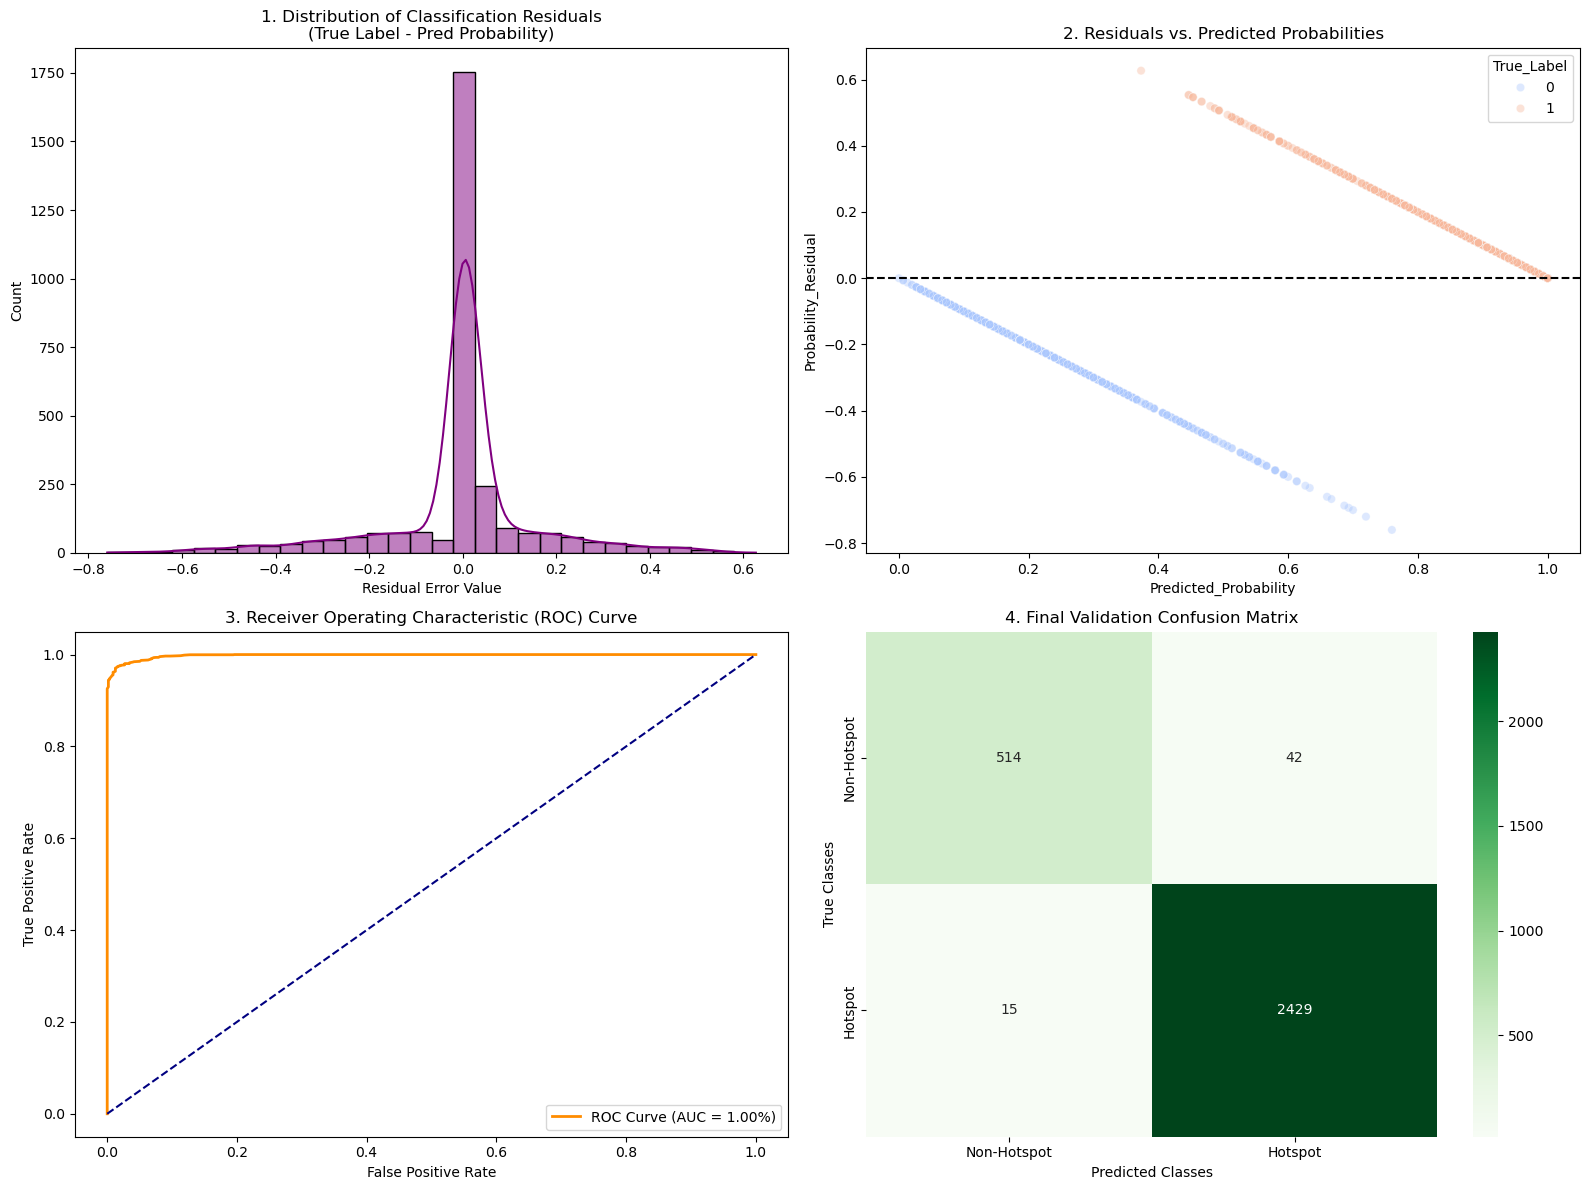

In [212]:
# Visualization of Model Performance & Classification Deviations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Distribution of Probability Residuals
sns.histplot(residual_df['Probability_Residual'], bins=30, kde=True, ax=axes[0, 0], color='purple')
axes[0, 0].set_title("1. Distribution of Classification Residuals\n(True Label - Pred Probability)")
axes[0, 0].set_xlabel("Residual Error Value")

# Residuals vs Predicted Probability (Error Mapping)
sns.scatterplot(x='Predicted_Probability', y='Probability_Residual', hue='True_Label', 
                data=residual_df, alpha=0.4, palette='coolwarm', ax=axes[0, 1])
axes[0, 1].axhline(0, color='black', linestyle='--')
axes[0, 1].set_title("2. Residuals vs. Predicted Probabilities")

# ROC Curve Analysis
fpr, tpr, _ = roc_curve(y_test, pred_prob)
auc_score = roc_auc_score(y_test, pred_prob)
axes[1, 0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.2f}%)')
axes[1, 0].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('3. Receiver Operating Characteristic (ROC) Curve')
axes[1, 0].legend(loc="lower right")

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[1, 1],
            xticklabels=['Non-Hotspot', 'Hotspot'], yticklabels=['Non-Hotspot', 'Hotspot'])
axes[1, 1].set_xlabel('Predicted Classes')
axes[1, 1].set_ylabel('True Classes')
axes[1, 1].set_title('4. Final Validation Confusion Matrix')

plt.tight_layout()
plt.show()

In [213]:
# Residual Extraction (Probability Deviation Evaluation)

# Generate predicted probabilities for the validation set
pred_prob = best_model.predict_proba(x_test)[:, 1]
predictions = best_model.predict(x_test)

# Calculate Classification Deviations (Probability Residuals)
prob_residuals = y_test - pred_prob

# Put into Dataframe for extraction
residual_df = pd.DataFrame({
    'True_Label': y_test,
    'Predicted_Probability': pred_prob,
    'Probability_Residual': prob_residuals,
    'Abs_Residual': np.abs(prob_residuals)
})

print("\nHead of the Extraction Residual DataFrame:")
print(residual_df.head(10))


Head of the Extraction Residual DataFrame:
       True_Label  Predicted_Probability  Probability_Residual  Abs_Residual
11499           1               0.993333              0.006667      0.006667
6475            1               1.000000              0.000000      0.000000
13167           1               0.753333              0.246667      0.246667
862             1               1.000000              0.000000      0.000000
5970            1               0.653333              0.346667      0.346667
6706            1               0.953333              0.046667      0.046667
3017            1               1.000000              0.000000      0.000000
3781            1               0.693333              0.306667      0.306667
3898            1               0.993333              0.006667      0.006667
2250            1               1.000000              0.000000      0.000000
